/Users/mateojimenez/Desktop/Mateo/Analisis_Predictivo_F1_Colapinto/.venv/lib/python3.12/site-packages/fastf1/plotting/_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Descargando datos de Melbourne 2026...


core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
/Users/mateojimenez/Desktop/Mateo/Analisis_Predictivo_F1_Colapinto/.venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Users/mateojimenez/Desktop/Mateo/Analisis_Predictivo_F1_Colapinto/.venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning:

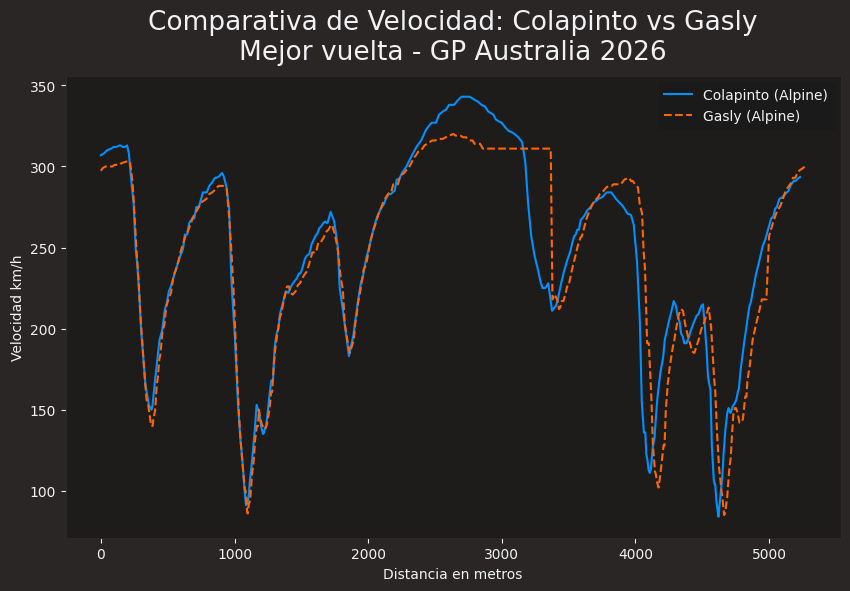

In [1]:
import os
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt


# 1. Definir el nombre de la carpeta
cache_dir = 'cache_f1'

# 2. Crear la carpeta si no existe
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# 3. Ahora sí, habilitar el caché
fastf1.Cache.enable_cache(cache_dir)


# 1. Configurar el estilo visual de la F1 y habilitar caché
plotting.setup_mpl(color_scheme='fastf1', misc_mpl_mods=True)
fastf1.Cache.enable_cache('cache_f1')

print("Descargando datos de Melbourne 2026...")

# 2. Cargar la sesión (Australia 2026 - Carrera)
session = fastf1.get_session(2026, 'Australia', 'R')
session.load()

# 3. Obtener la vuelta mas rápida de cada uno
laps_col = session.laps.pick_driver('COL').pick_fastest()
laps_gas= session.laps.pick_driver('GAS').pick_fastest()

# 4. Obtener telemetría y añadir la distancia recorrida para el eje X
tel_col = laps_col.get_telemetry().add_distance()
tel_gas = laps_gas.get_telemetry().add_distance()

# 5. Graficar la velocidad 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tel_col['Distance'], tel_col['Speed'], label='Colapinto (Alpine)', color='#0090FF')
ax.plot(tel_gas['Distance'], tel_gas['Speed'], label='Gasly (Alpine)', color='#FF6600', linestyle='--')

ax.set_xlabel('Distancia en metros')
ax.set_ylabel('Velocidad km/h')
ax.set_title('Comparativa de Velocidad: Colapinto vs Gasly\nMejor vuelta - GP Australia 2026')
ax.legend()

plt.show()